# DATA PREPARATION

In [19]:
# INITIATION: PYTHON AND DISPLAY

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts

# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [20]:
# FILE LOAD

# Read the Excel file into a DataFrame
df_filter = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')

# GRAPHICAL ANALYSIS

In [21]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A TABLE

def analyze_combinations(data, year, columns_to_analyze, split_by_column, result_filename=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Create a pivot table to split results by the specified column
    pivot_table = pd.pivot_table(
        data_filtered,
        values='Name',  # 'Name' is used to count occurrences
        index='Combination',
        columns=split_by_column,
        aggfunc='count',
        fill_value=0,
        observed=False  # Explicitly set observed=False to avoid the warning
    )

    # Step 4: Add a Total column to the pivot table
    pivot_table['Total'] = pivot_table.sum(axis=1)

    # Step 5: Add a Total row for all combinations
    pivot_table.loc['Total'] = pivot_table.sum(axis=0)

    # Step 6: Calculate the proportions
    proportions_table = pivot_table.div(pivot_table.loc['Total'], axis=1).map(lambda x: f"{x:.2%}")

    # Display the tables side by side using HTML
    html_table = f"""
    <div style="display: flex; justify-content: flex-start; gap: 1cm;">
        <div>
            <h3>Counts of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {pivot_table.to_html()}
        </div>
        <div>
            <h3>Proportions of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {proportions_table.to_html()}
        </div>
    </div>
    """
    display(HTML(html_table))

    # Save the pivot and proportions tables to an Excel file if a filename is provided
    if result_filename:
        with pd.ExcelWriter(result_filename) as writer:
            pivot_table.to_excel(writer, sheet_name='Counts')
            proportions_table.to_excel(writer, sheet_name='Proportions')
        print(f"Results saved to {result_filename}")

In [22]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A CHART

def create_chart(data, year, columns_to_analyze, split_by_column=None, filter_value=None, title=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Apply additional filtering if needed (e.g., split by a column value like 'P' or 'F')
    if split_by_column and filter_value:
        data_filtered = data_filtered[data_filtered[split_by_column] == filter_value]

    # Step 4: Calculate total counts for each combination
    combination_counts = data_filtered['Combination'].value_counts()

    # Step 5: Determine positions based on the number of columns
    if len(columns_to_analyze) == 2:
        positions = {
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} Yes": (0.75, 0.75),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} Yes": (0.25, 0.75),
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} No": (0.75, 0.25),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} No": (0.25, 0.25)
        }
    else:
        raise ValueError("This chart only supports 2 columns for analysis.")

    x_labels = ['No', 'Yes']
    y_labels = ['No', 'Yes']

    # Step 6: Plot the data
    fig, ax = plt.subplots(figsize=(8, 8))

    for combination, (x, y) in positions.items():
        count = combination_counts.get(combination, 0)
        ax.scatter(x, y, s=count*70, alpha=0.6, color='#4CAF50', edgecolor='black')
        ax.text(x, y, f'{count}', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(x_labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(y_labels)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(columns_to_analyze[0], fontsize=14)
    ax.set_ylabel(columns_to_analyze[1], fontsize=14)
    ax.axhline(0.5, color='black', linewidth=1)
    ax.axvline(0.5, color='black', linewidth=1)
    
    if title:
        plt.title(title, fontsize=16)
    
    plt.tight_layout()
    plt.show()

In [23]:
# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['Drop_Sales', 'Hint'], 
    split_by_column='Growth_Category',
    result_filename='hg_hint_combinations_2022.xlsx'
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['P/F', 'Drop_Sales'], 
    split_by_column='Growth_Category',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Drop_Sales'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'Hint'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'G3'], 
    split_by_column='P/F',
)

Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
Drop_Sales No & Hint No,30,148,109,61,348
Drop_Sales No & Hint Yes,13,99,89,51,252
Drop_Sales Yes & Hint No,217,172,65,36,490
Drop_Sales Yes & Hint Yes,162,166,50,32,410
Total,422,585,313,180,1500
Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
Drop_Sales No & Hint No,7.11%,25.30%,34.82%,33.89%,23.20%
Drop_Sales No & Hint Yes,3.08%,16.92%,28.43%,28.33%,16.80%


Results saved to hg_hint_combinations_2022.xlsx


Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
P/F No & Drop_Sales No,43,247,198,112,600
P/F No & Drop_Sales Yes,379,338,115,68,900
Total,422,585,313,180,1500
Growth_Category,G0,G1,G2,G3,Total
Combination,,,,,
P/F No & Drop_Sales No,10.19%,42.22%,63.26%,62.22%,40.00%
P/F No & Drop_Sales Yes,89.81%,57.78%,36.74%,37.78%,60.00%
Total,100.00%,100.00%,100.00%,100.00%,100.00%


P/F,F,P,Total
Combination,,,
G3 No & Drop_Sales No,230,258,488
G3 No & Drop_Sales Yes,453,379,832
G3 Yes & Drop_Sales No,41,71,112
G3 Yes & Drop_Sales Yes,20,48,68
Total,744,756,1500
P/F,F,P,Total
Combination,,,
G3 No & Drop_Sales No,30.91%,34.13%,32.53%
G3 No & Drop_Sales Yes,60.89%,50.13%,55.47%


P/F,F,P,Total
Combination,,,
G2 No & Hint No,284,380,664
G2 No & Hint Yes,336,187,523
G2 Yes & Hint No,57,117,174
G2 Yes & Hint Yes,67,72,139
Total,744,756,1500
P/F,F,P,Total
Combination,,,
G2 No & Hint No,38.17%,50.26%,44.27%
G2 No & Hint Yes,45.16%,24.74%,34.87%


P/F,F,P,Total
Combination,,,
G2 No & G3 No,559,448,1007
G2 No & G3 Yes,61,119,180
G2 Yes & G3 No,124,189,313
Total,744,756,1500
P/F,F,P,Total
Combination,,,
G2 No & G3 No,75.13%,59.26%,67.13%
G2 No & G3 Yes,8.20%,15.74%,12.00%
G2 Yes & G3 No,16.67%,25.00%,20.87%


In [24]:
# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['HEG', 'Hint'], 
    split_by_column='P/F',
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['HEG', 'G3'], 
    split_by_column='P/F',
)

P/F,F,P,Total
Combination,,,
HEG No & Hint No,155,210,365
HEG No & Hint Yes,189,103,292
HEG Yes & Hint No,186,287,473
HEG Yes & Hint Yes,214,156,370
Total,744,756,1500
P/F,F,P,Total
Combination,,,
HEG No & Hint No,20.83%,27.78%,24.33%
HEG No & Hint Yes,25.40%,13.62%,19.47%


P/F,F,P,Total
Combination,,,
HEG No & G3 No,332,289,621
HEG No & G3 Yes,12,24,36
HEG Yes & G3 No,351,348,699
HEG Yes & G3 Yes,49,95,144
Total,744,756,1500
P/F,F,P,Total
Combination,,,
HEG No & G3 No,44.62%,38.23%,41.40%
HEG No & G3 Yes,1.61%,3.17%,2.40%


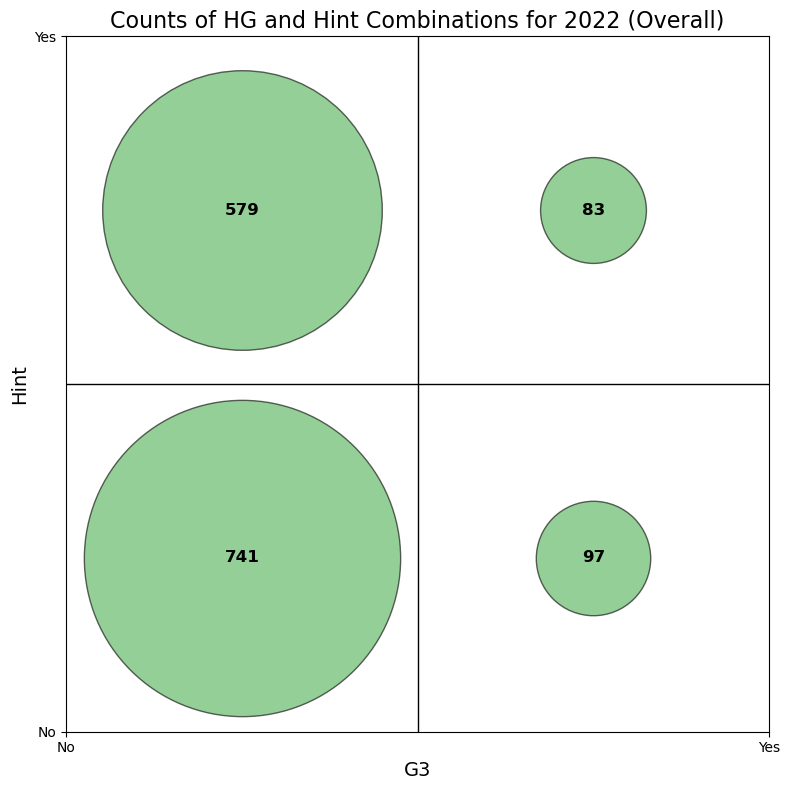

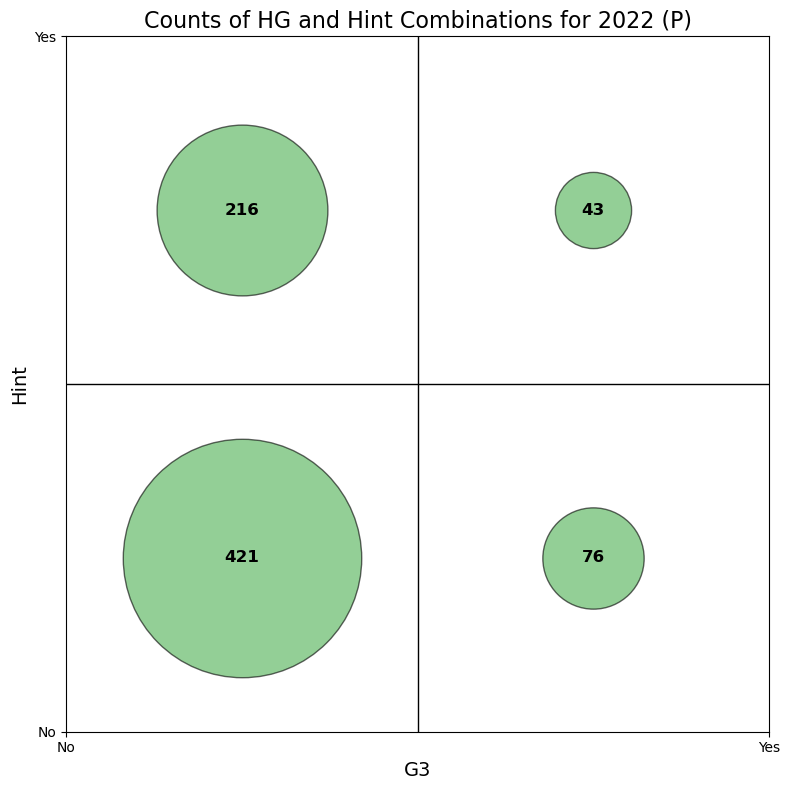

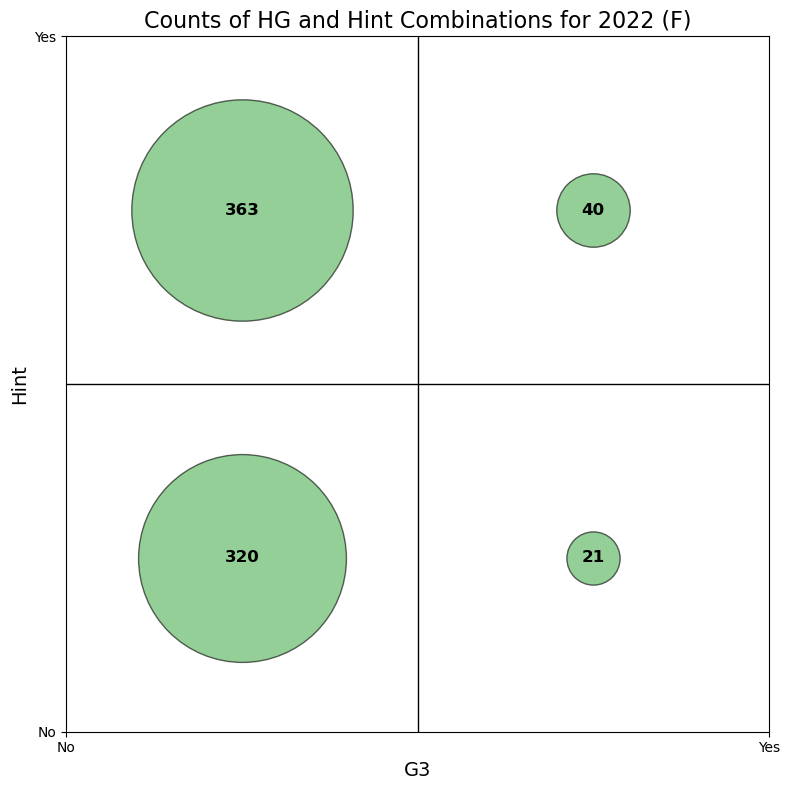

In [25]:
# CHART FUNCTION EXECUTION

# Generate a chart for overall data
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    title='Counts of HG and Hint Combinations for 2022 (Overall)'
)

# Generate a chart for the 'P' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    split_by_column='P/F', 
    filter_value='P', 
    title='Counts of HG and Hint Combinations for 2022 (P)'
)

# Generate a chart for the 'F' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'Hint'], 
    split_by_column='P/F', 
    filter_value='F', 
    title='Counts of HG and Hint Combinations for 2022 (F)'
)

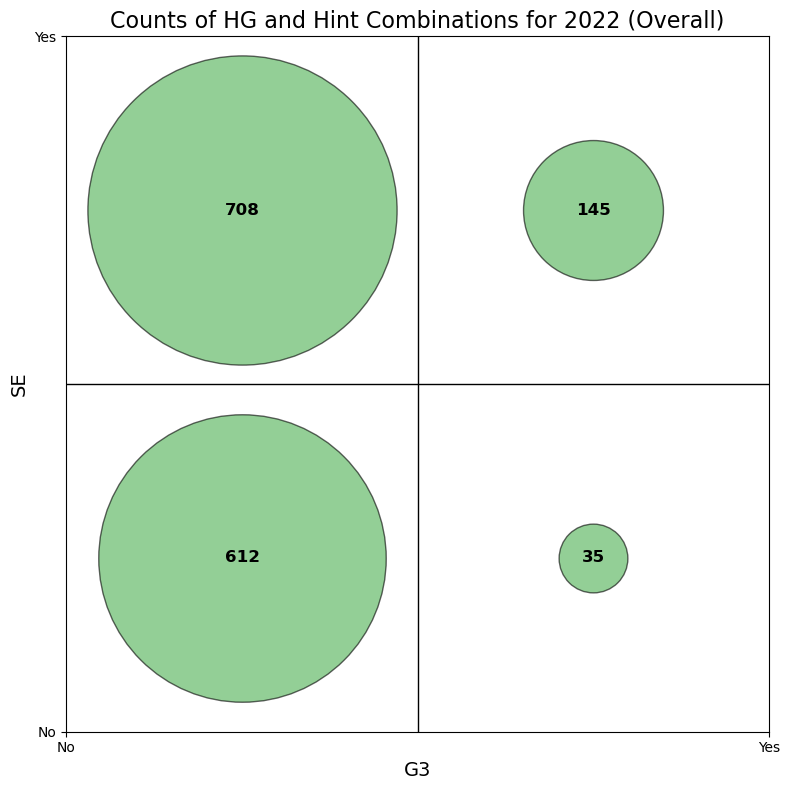

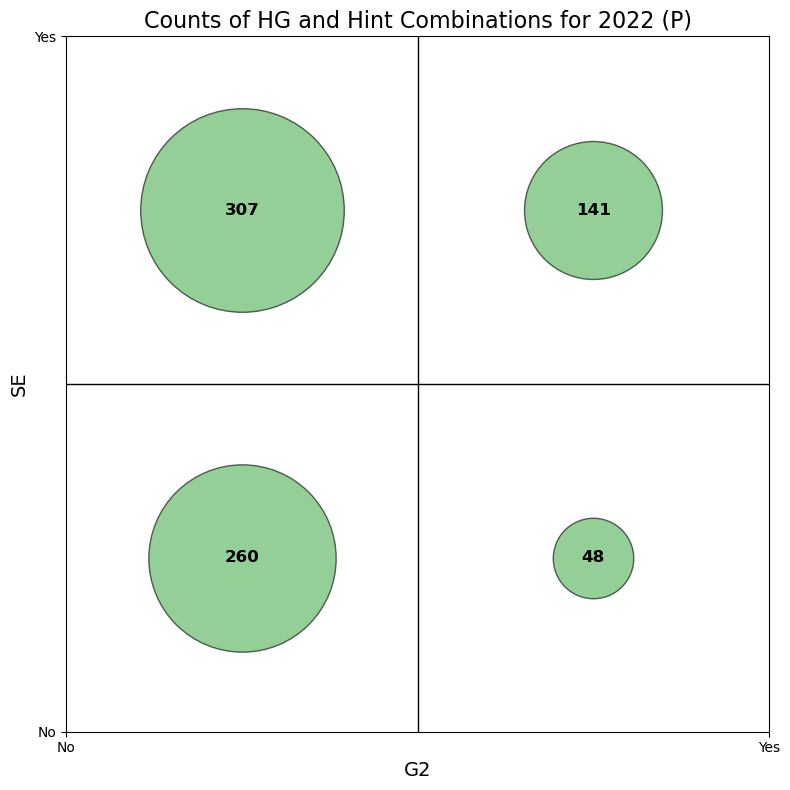

In [26]:
# CHART FUNCTION EXECUTION

# Generate a chart for overall data
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G3', 'SE'], 
    title='Counts of HG and Hint Combinations for 2022 (Overall)'
)

# Generate a chart for the 'P' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2022, 
    columns_to_analyze=['G2', 'SE'], 
    split_by_column='P/F', 
    filter_value='P', 
    title='Counts of HG and Hint Combinations for 2022 (P)'
)

In [27]:
# Filter the data to find companies that experienced both Drop_Sales and have HG

name_filter = df_filter[(df_filter['Drop_Sales'] == 'Yes') & (df_filter['G3'] == 'Yes')][['Name', 'Sales','P/F']]

display(name_filter)

,Name,Sales,P/F
10,"Jastrzębska Spółka Węglowa SA, Jastrzębie–Zdrój","25 770 900,00",P
11,"Polskie Sieci Elektroenergetyczne SA, Konstancin","25 473 210,91",P
12,"Grupa Azoty SA GK, Tarnów","24 657 853,00",P
31,"Shell Polska sp. z o.o, Warszawa","13 424 447,00",F
62,"Grupa Azoty Zakłady Azotowe Puławy SA GK, Puławy","8 898 737,00",P
70,"Węglokoks SA GK, Katowice","7 890 801,00",P
74,"CMC Poland sp. z o.o., Zawiercie","7 220 637,00",F
80,"Polenergia SA GK, Warszawa","7 089 231,00",P
94,"Arcturus Bunker sp. z o.o., Szczecin","6 403 160,60",P
104,"Anwil SA, Włocławek","5 736 650,00",P


In [34]:
# OLS Regression Model
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Filter the data for the year 2022
df_2022 = df_filter[df_filter['Year'] == 2022]

# Remove rows with missing values in the relevant columns
df_2022_cleaned = df_2022.dropna(subset=['P/F', 'G3','Hint','Drop_Sales','Drop_Employment','Starting_Size','Starting_Profit','Human_Capital', 'PKD_2','LSGrowth_2022_2019'])

# Define the dependent variable
y_2022 = df_2022_cleaned['LSGrowth_2022_2019']

# Define the independent variables
X_2022 = df_2022_cleaned[['P/F', 'G3','Hint','Drop_Sales','Drop_Employment','Starting_Size','Starting_Profit','Human_Capital', 'PKD_2']]

# Convert categorical variables to dummies
X_2022 = pd.get_dummies(X_2022, drop_first=True)

# Add a constant to the model (intercept)
X_2022 = sm.add_constant(X_2022)

# Convert all boolean columns in the DataFrame to integers
for col in X_2022.columns:
    if X_2022[col].dtype == 'bool':
        X_2022[col] = X_2022[col].map({True: 1, False: 0})

# Fit the OLS model
model_2022 = sm.OLS(y_2022, X_2022).fit()

# Show the summary of the regression
print(model_2022.summary())

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_2022.columns
vif_data['VIF'] = [variance_inflation_factor(X_2022.values, i) for i in range(X_2022.shape[1])]

# Show the VIF results
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:     LSGrowth_2022_2019   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     169.6
Date:                Thu, 24 Oct 2024   Prob (F-statistic):          1.84e-220
Time:                        10:17:41   Log-Likelihood:                -26.154
No. Observations:                1488   AIC:                             72.31
Df Residuals:                    1478   BIC:                             125.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.0850    

,Average Sales (in billions),ROA (%),ROS (%),ROE (%)
Growth_Category,,,,
G0,"1 595 146,59","3,39","2,65","8,02"
G1,"1 817 218,02","6,41","4,79","15,16"
G2,"2 474 704,53","5,06","4,10","11,42"
G3,"3 536 041,82","9,01","4,74","21,57"


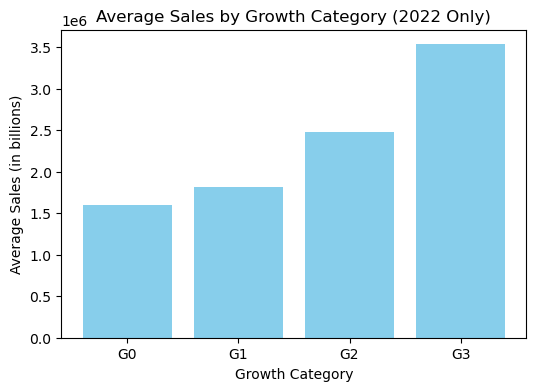

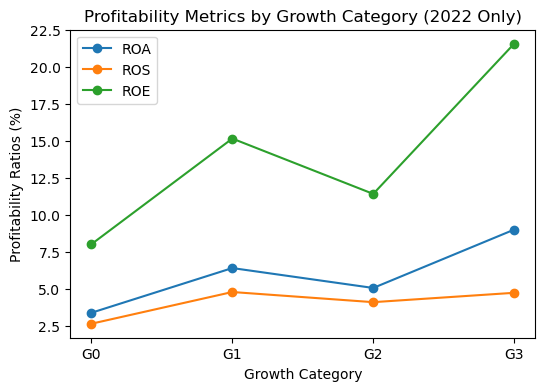

In [35]:
# Step 1: Calculate average sales by growth category for the year 2022
unique_growth_sales_2022 = df_2022.groupby('Growth_Category')['Sales'].mean()

# Step 2: Calculate profitability metrics (ROA, ROS, ROE) by growth category for 2022 using actual calculation
# ROA = Net Profit / Total Assets
# ROS = Net Profit / Sales
# ROE = Net Profit / Equity

growth_assets_2022 = df_2022.groupby('Growth_Category')['BS'].sum()
growth_sales_2022 = df_2022.groupby('Growth_Category')['Sales'].sum()
growth_net_profit_2022 = df_2022.groupby('Growth_Category')['Net Profit'].sum()
growth_equity_2022 = df_2022.groupby('Growth_Category')['Equity'].sum()

unique_growth_roa_2022 = (growth_net_profit_2022 / growth_assets_2022) * 100
unique_growth_ros_2022 = (growth_net_profit_2022 / growth_sales_2022) * 100
unique_growth_roe_2022 = (growth_net_profit_2022 / growth_equity_2022) * 100

# Display the results as a table
profitability_df = pd.DataFrame({
    'Average Sales (in billions)': unique_growth_sales_2022,
    'ROA (%)': unique_growth_roa_2022,
    'ROS (%)': unique_growth_ros_2022,
    'ROE (%)': unique_growth_roe_2022
})

from IPython.display import display

display(profitability_df)

# Step 3: Plot the charts for 2022 data

# Plot: Average Sales by Growth Category (2022 only)
plt.figure(figsize=(6, 4))
plt.bar(unique_growth_sales_2022.index, unique_growth_sales_2022, color='skyblue')
plt.title('Average Sales by Growth Category (2022 Only)')
plt.ylabel('Average Sales (in billions)')
plt.xlabel('Growth Category')
plt.show()

# Plot: Profitability Metrics (ROA, ROS, ROE) by Growth Category (2022 only)
plt.figure(figsize=(6, 4))
plt.plot(unique_growth_roa_2022.index, unique_growth_roa_2022, label='ROA', marker='o')
plt.plot(unique_growth_ros_2022.index, unique_growth_ros_2022, label='ROS', marker='o')
plt.plot(unique_growth_roe_2022.index, unique_growth_roe_2022, label='ROE', marker='o')
plt.title('Profitability Metrics by Growth Category (2022 Only)')
plt.ylabel('Profitability Ratios (%)')
plt.xlabel('Growth Category')
plt.legend()
plt.show()


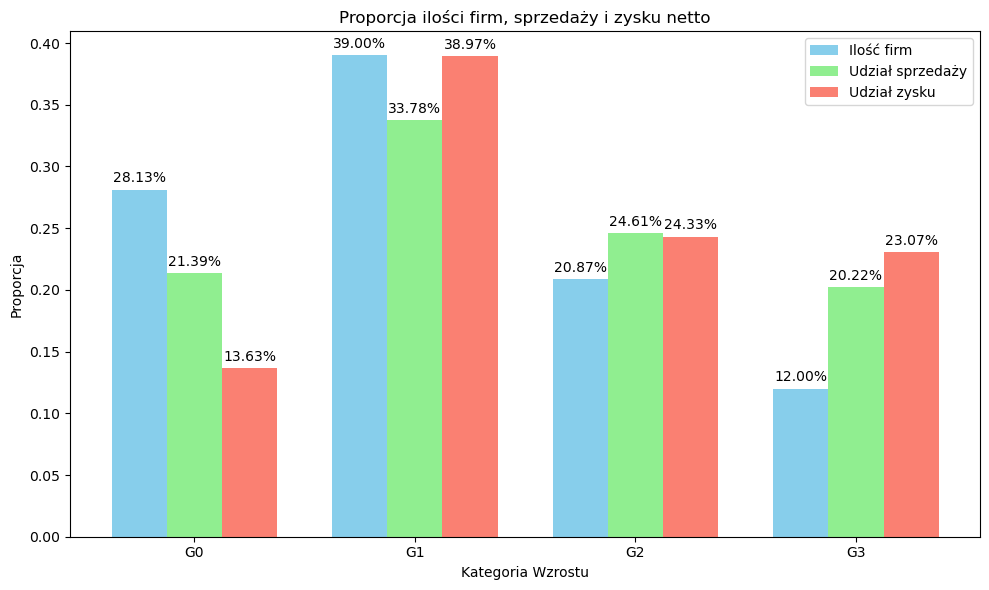

In [36]:
# Total count by Growth Category
total_count = df_2022['Growth_Category'].value_counts(normalize=True)

# Total sales by Growth Category
total_sales = df_2022.groupby('Growth_Category')['Sales'].sum()
sales_proportion = total_sales / total_sales.sum()

# Total net profit by Growth Category (use existing Net Profit column)
total_net_profit = df_2022.groupby('Growth_Category')['Net Profit'].sum()
net_profit_proportion = total_net_profit / total_net_profit.sum()

# Create a DataFrame to display the proportions
proportions_df = pd.DataFrame({
    'Count Proportion': total_count,
    'Sales Proportion': sales_proportion,
    'Net Profit Proportion': net_profit_proportion
})

# Data preparation
categories = proportions_df.index
count_prop = proportions_df['Count Proportion']
sales_prop = proportions_df['Sales Proportion']
net_profit_prop = proportions_df['Net Profit Proportion']

x = np.arange(len(categories))  # label locations
width = 0.25  # width of the bars

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for Count, Sales, and Net Profit proportions
bars1 = ax.bar(x - width, count_prop, width, label='Ilość firm', color='skyblue')
bars2 = ax.bar(x, sales_prop, width, label='Udział sprzedaży', color='lightgreen')
bars3 = ax.bar(x + width, net_profit_prop, width, label='Udział zysku', color='salmon')

# Adding labels, title, and customizations
ax.set_xlabel('Kategoria Wzrostu')
ax.set_ylabel('Proporcja')
ax.set_title('Proporcja ilości firm, sprzedaży i zysku netto')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Adding percentage labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}',  # Display values as percentages
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()

# Save the chart as an image
plt.savefig('count sales and net profit.png')

plt.show()

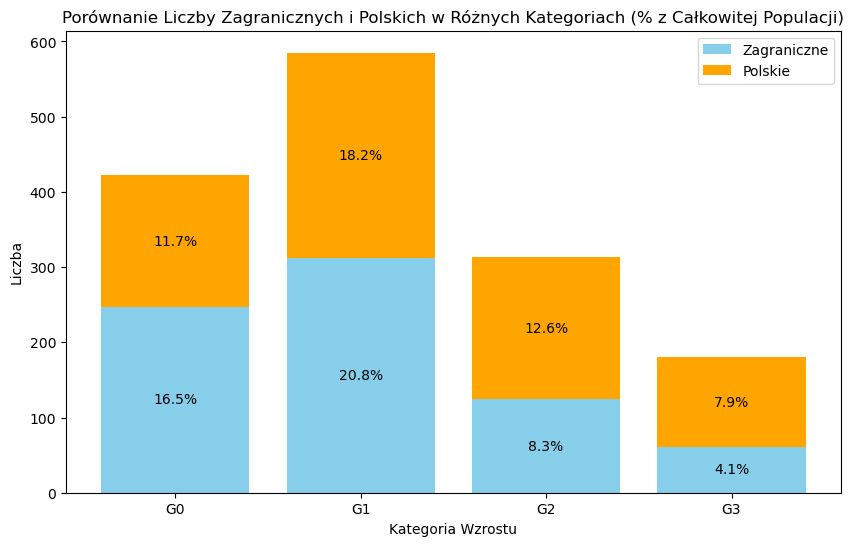

In [37]:
# Extract relevant columns: Growth_Category and P/F for the year 2022
aggregation_df = df_2022[['Growth_Category', 'P/F']].copy()

# Count the number of occurrences per Growth_Category and P/F for 2022 using the P/F column directly
aggregated_data = aggregation_df.groupby(['Growth_Category', 'P/F']).size().reset_index(name='Count')

# Pivot the table for easier plotting
pivot_table = aggregated_data.pivot(index='Growth_Category', columns='P/F', values='Count').fillna(0)

# Extract the required data for plotting
categories = pivot_table.index
zagraniczne = pivot_table['F'] if 'F' in pivot_table else [0] * len(categories)
polskie = pivot_table['P'] if 'P' in pivot_table else [0] * len(categories)

# Calculate the total count for the entire population for percentage calculations
total_count = zagraniczne.sum() + polskie.sum()
percent_zagraniczne_total = (zagraniczne / total_count) * 100
percent_polskie_total = (polskie / total_count) * 100

# Create the stacked bar chart
plt.figure(figsize=(10, 6))
bars1 = plt.bar(categories, zagraniczne, label='Zagraniczne', color='skyblue')
bars2 = plt.bar(categories, polskie, bottom=zagraniczne, label='Polskie', color='orange')

# Add percentage labels within the bars as % of total population
for bar, value, percentage in zip(bars1, zagraniczne, percent_zagraniczne_total):
    plt.text(bar.get_x() + bar.get_width() / 2, value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom, value, percentage in zip(bars2, zagraniczne, polskie, percent_polskie_total):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

plt.xlabel('Kategoria Wzrostu')
plt.ylabel('Liczba')
plt.title('Porównanie Liczby Zagranicznych i Polskich w Różnych Kategoriach (% z Całkowitej Populacji)')
plt.legend()

# Save the chart as an image
plt.savefig('stacked_bar_chart.png')

plt.show()


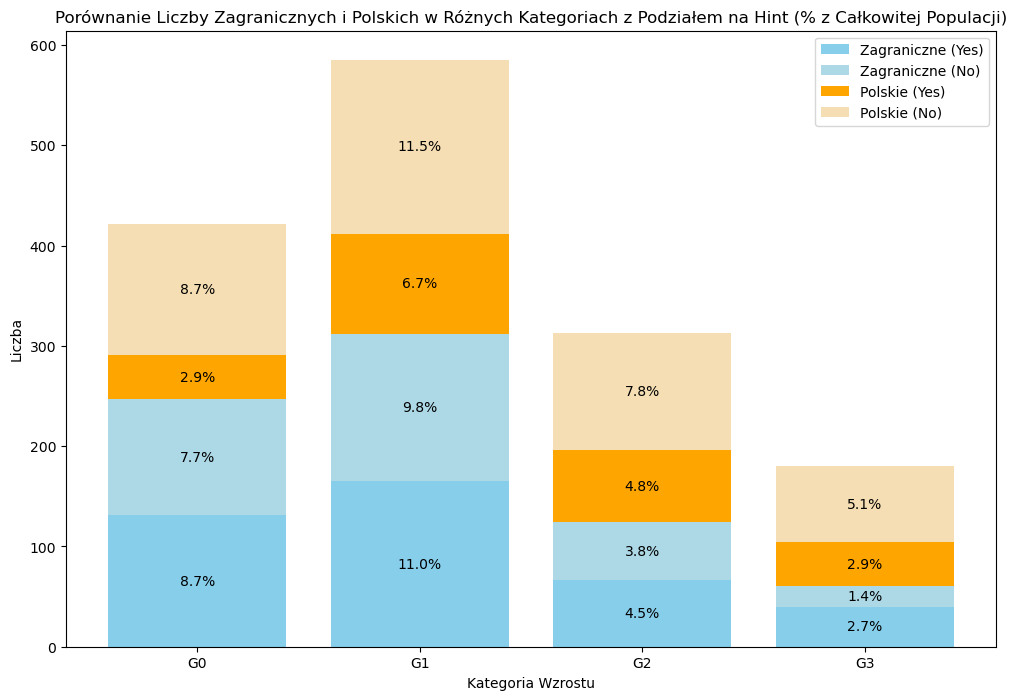

In [38]:
# Extract relevant columns: Growth_Category, P/F, and Hint for the year 2022
aggregation_df = df_2022[['Growth_Category', 'P/F', 'Hint']].copy()

# Count the number of occurrences per Growth_Category, P/F, and Hint for 2022
aggregated_data = aggregation_df.groupby(['Growth_Category', 'P/F', 'Hint']).size().reset_index(name='Count')

# Pivot the table for easier plotting
pivot_table = aggregated_data.pivot_table(index='Growth_Category', columns=['P/F', 'Hint'], values='Count', fill_value=0)

# Extract the required data for plotting
categories = pivot_table.index

# Prepare data for plotting
zagraniczne_yes = pivot_table[('F', 'Yes')] if ('F', 'Yes') in pivot_table else [0] * len(categories)
zagraniczne_no = pivot_table[('F', 'No')] if ('F', 'No') in pivot_table else [0] * len(categories)
polskie_yes = pivot_table[('P', 'Yes')] if ('P', 'Yes') in pivot_table else [0] * len(categories)
polskie_no = pivot_table[('P', 'No')] if ('P', 'No') in pivot_table else [0] * len(categories)

# Calculate the total count for the entire population for percentage calculations
total_count = zagraniczne_yes.sum() + zagraniczne_no.sum() + polskie_yes.sum() + polskie_no.sum()
percent_zagraniczne_yes = (zagraniczne_yes / total_count) * 100
percent_zagraniczne_no = (zagraniczne_no / total_count) * 100
percent_polskie_yes = (polskie_yes / total_count) * 100
percent_polskie_no = (polskie_no / total_count) * 100

# Create the stacked bar chart
plt.figure(figsize=(12, 8))
bars1 = plt.bar(categories, zagraniczne_yes, label='Zagraniczne (Yes)', color='skyblue')
bars2 = plt.bar(categories, zagraniczne_no, bottom=zagraniczne_yes, label='Zagraniczne (No)', color='lightblue')
bars3 = plt.bar(categories, polskie_yes, bottom=zagraniczne_yes + zagraniczne_no, label='Polskie (Yes)', color='orange')
bars4 = plt.bar(categories, polskie_no, bottom=zagraniczne_yes + zagraniczne_no + polskie_yes, label='Polskie (No)', color='wheat')

# Add percentage labels within the bars as % of total population
for bar, value, percentage in zip(bars1, zagraniczne_yes, percent_zagraniczne_yes):
    plt.text(bar.get_x() + bar.get_width() / 2, value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom, value, percentage in zip(bars2, zagraniczne_yes, zagraniczne_no, percent_zagraniczne_no):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom1, bottom2, value, percentage in zip(bars3, zagraniczne_yes, zagraniczne_no, polskie_yes, percent_polskie_yes):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom1 + bottom2 + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom1, bottom2, bottom3, value, percentage in zip(bars4, zagraniczne_yes, zagraniczne_no, polskie_yes, polskie_no, percent_polskie_no):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom1 + bottom2 + bottom3 + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

plt.xlabel('Kategoria Wzrostu')
plt.ylabel('Liczba')
plt.title('Porównanie Liczby Zagranicznych i Polskich w Różnych Kategoriach z Podziałem na Hint (% z Całkowitej Populacji)')
plt.legend()

# Save the chart as an image
plt.savefig('stacked_bar_chart_with_hint.png')

plt.show()

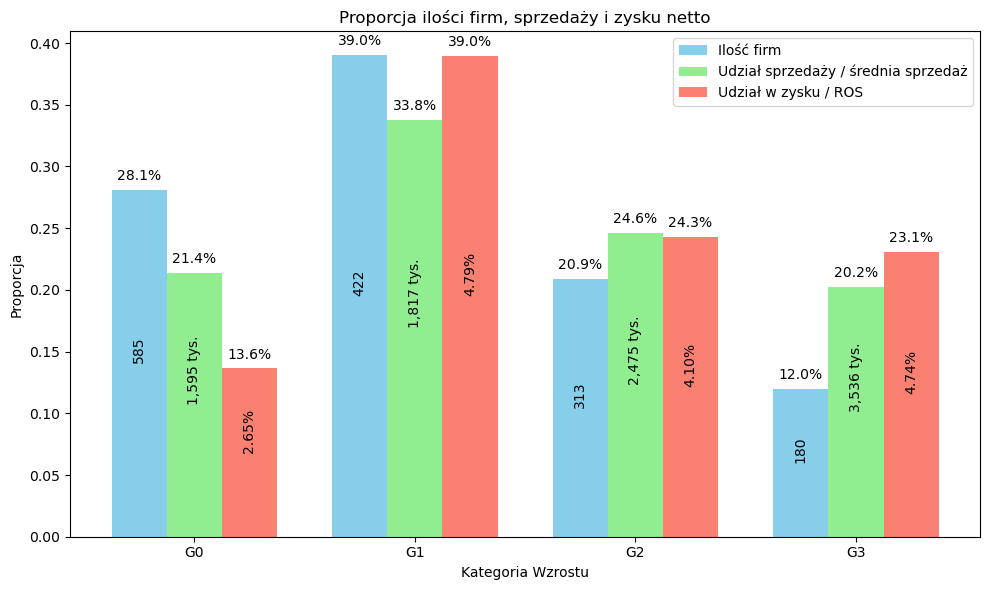

In [39]:
# Step 1: Total count, sales, and net profit by growth category
# Total count by Growth Category
total_count = df_2022['Growth_Category'].value_counts()

# Total sales by Growth Category
total_sales = df_2022.groupby('Growth_Category')['Sales'].sum()
sales_proportion = total_sales / total_sales.sum()

# Total net profit by Growth Category (use existing Net Profit column)

# Calculate ROS (Return on Sales) by Growth Category
unique_growth_ros_2022 = (total_net_profit / total_sales) * 100
total_net_profit = df_2022.groupby('Growth_Category')['Net Profit'].sum()
net_profit_proportion = total_net_profit / total_net_profit.sum()

# Create a DataFrame to display the proportions
proportions_df = pd.DataFrame({
    'Count Proportion': total_count / total_count.sum(),
    'Sales Proportion': sales_proportion,
    'Net Profit Proportion': net_profit_proportion
})

# Data preparation
categories = proportions_df.index
count_prop = proportions_df['Count Proportion']
sales_prop = proportions_df['Sales Proportion']
net_profit_prop = proportions_df['Net Profit Proportion']

x = np.arange(len(categories))  # label locations
width = 0.25  # width of the bars

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for Count, Sales, and Net Profit proportions
bars1 = ax.bar(x - width, count_prop, width, label='Ilość firm', color='skyblue')
bars2 = ax.bar(x, sales_prop, width, label='Udział sprzedaży / średnia sprzedaż', color='lightgreen')
bars3 = ax.bar(x + width, net_profit_prop, width, label='Udział w zysku / ROS', color='salmon')

# Adding labels, title, and customizations
ax.set_xlabel('Kategoria Wzrostu')
ax.set_ylabel('Proporcja')
ax.set_title('Proporcja ilości firm, sprzedaży i zysku netto')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Adding numbers inside bars in a user-friendly format and adding % proportions above bars
def add_labels(bars, values, format_type):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if format_type == 'count':
            label = f'{int(value)}'
        elif format_type == 'sales':
            label = f'{value:,.0f} tys.'
        elif format_type == 'ros':
            label = f'{value:.2f}%'
        # Display the actual value in formatted form vertically inside the bar
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width() / 2, height / 2),
                    xytext=(0, 0),
                    textcoords="offset points",
                    ha='center', va='bottom', rotation='vertical', color='black')
        # Display the percentage proportion above the bar
        ax.annotate(f'{height:.1%}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', color='black')

# Adding specific values for each bar type
add_labels(bars1, total_count, 'count')
add_labels(bars2, unique_growth_sales_2022 / 1000, 'sales')  # Display average sales in thousands
add_labels(bars3, unique_growth_ros_2022, 'ros')  # Display ROS in percentage

plt.tight_layout()

# Save the chart as an image
plt.savefig('count sales and net profit.png')

plt.show()
